## **Modelagem: Random Forest**

Neste notebook vamos construir e avaliar um modelo de classificação Random Forest para prever os funcionários que pedirão demissão voluntária.

O Random Forest (RF) será nosso segundo modelo e vamos compará-lo com a regressão logística, nosso baseline. 

O processo de modelagem seguirá as seguintes etapas:

- **Pipeline de transformações**: vamos definir um pipeline de transformadores para preparar nossos dados.

- **Tuning do modelo**: vamos usar 10 dobras de validação cruzada para treinar e validar 150 modelos diferentes, com hiperparâmetros aleatóriamente escolhido no espaço de parâmetros possíveis. Vamos optar pelo modelo que melhor equilibra `recall` e `roc_auc`. 

- **Treinamento do melhor modelo**: vamos selecionar os hiperparâmetros do melhor modelo e treiná-lo no conjunto completo de treinamento

- **Métricas de avaliação no treinamento**: vamos avaliar a acurácia, curva ROC, precisão, recall e f1-score no conjunto de treinamento.

---

Obs: A análise da interpretabiliade será feita com o modelo final escolhido, bem como o teste no conjunto de testes. 

## Importação de Bibliotecas

Nesta etapa são importadas todas as bibliotecas necessárias para **pré-processamento, modelagem e busca de hiperparâmetros**:

1. **Bibliotecas gerais**
   - `numpy` e `pandas`: manipulação de arrays e DataFrames.  
   - `matplotlib.pyplot`: geração de gráficos.  
   - `joblib`: salvar e carregar objetos treinados (como modelos e pipelines).

2. **Transformadores (scikit-learn)**
   - `ColumnTransformer`: aplica diferentes transformações a grupos de colunas.  
   - `OneHotEncoder`, `OrdinalEncoder`, `StandardScaler`, `TargetEncoder`: transformações para variáveis categóricas, ordinais e numéricas.  
   - `PolynomialFeatures`: cria novas features polinomiais a partir das originais.  
   - `KNNImputer`: imputação de valores ausentes com base nos vizinhos mais próximos.  
   - `Pipeline`: encadeia as etapas de pré-processamento e modelagem.

3. **Modelos**
   - `RandomForestClassifier`: modelo estatístico base usado para classificação.

4. **Busca de hiperparâmetros**
   - `loguniform`, `uniform`: distribuições de probabilidade usadas para amostragem de hiperparâmetros.  
   - `RandomizedSearchCV`: busca aleatória sobre o espaço de hiperparâmetros, combinando treino e validação cruzada.

---

👉 Essas importações organizam as ferramentas que serão usadas para **construir, ajustar e otimizar** o pipeline de machine learning.


In [1]:
### libs ###
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

### Transformadores ###

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, TargetEncoder, PolynomialFeatures
from sklearn.impute import KNNImputer,SimpleImputer
from sklearn.pipeline import Pipeline

### Modelos ###

from sklearn.ensemble import RandomForestClassifier



### Randomized Search ###
from scipy.stats import loguniform, uniform
from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV


## Carregamento dos Dados de Treino

Neste passo, os arquivos de treino previamente salvos em **CSV** são carregados para o ambiente:

1. **`X_train.csv`**  
   - Contém as variáveis preditoras (features) já separadas para treino.  
   - É lido em um DataFrame `X_train`.

2. **`y_train.csv`**  
   - Contém apenas a variável alvo (target), indicando o desfecho que se deseja prever.  
   - É lido em um DataFrame `y_train`.

---

👉 Esses arquivos foram gerados anteriormente no processo de preparação dos dados (divisão treino/teste) e agora serão usados como entrada para o pipeline de modelagem.


In [2]:
# Carregar os dados
X_train = pd.read_csv("X_train.csv")
y_train = pd.read_csv("y_train.csv")


In [3]:
#Random Forest

### 🗂️ Definição dos grupos de variáveis

Antes de aplicar o pré-processamento, organizamos as variáveis do dataset em grupos, de acordo com sua natureza.  
Essa separação é importante porque cada tipo de variável requer um tratamento específico (imputação, codificação, escalonamento etc.).

- **Binárias (`binarias`)**: variáveis categóricas com apenas duas categorias possíveis (ex.: `catl_sexo`, `catl_doenca_cronica`).
- **Numéricas (`numericas`)**: variáveis quantitativas contínuas ou discretas (ex.: `num_idade`, `num_consultas`).
- **Ordinais (`ordinais`)**: variáveis categóricas que possuem uma ordem natural entre os valores (ex.: `ord_saude`, `ord_remedio_semana`).
- **Categóricas (`categoricas`)**: variáveis qualitativas sem ordem definida (ex.: `catl_cor_raca`, `cath_fonte_de_agua`).
- **Alta cardinalidade (`alta_cardinalidade`)**: variáveis categóricas com grande número de categorias distintas, que serão tratadas com `TargetEncoder` (ex.: `cath_trabalho`, `cath_destino_do_esgoto`).

Esses grupos são usados no `ColumnTransformer` para garantir que cada tipo de dado receba o pré-processamento adequado.


In [4]:
# 1) Grupos de variáveis
tipos_variaveis1 = {
    "binarias": [
        "catl_sexo","catl_doenca_cronica","catl_animais","catl_homeopatia",
        "catl_internacao","catl_quimicos","catl_ruidos","catl_sol",
        "catl_material_biologico","catl_plano_saude","catl_medicamentos",
        "catl_plantas_medicinais","catl_deixar_atividades","catl_servico_saude",
        "catl_recebeu_atendimento","catl_lixo","catl_poeira_mineral",
        "catl_plano_consultas","catl_plano_exames","catl_plano_internacoes",
        "catl_cigarro","catl_pagou_remedio","catl_domicilio_cadastrado"
    ],

    "numericas": [
        "num_idade","catl_cachoros","catl_gatos","num_consultas"
    ],

    "ordinais": [
        "ord_saude","ord_agente_saude",
        "ord_nivel_plano","ord_remedio_semana","ord_remedio_sus",
        "ord_farmacia_popular"
    ],

    "categoricas": [
        "catl_cor_raca","catl_tipo_de_area","catl_tipo_de_domicilio",
        "cath_material_parede","cath_fonte_de_agua",
        "catl_destino_do_lixo","catl_atividade","cath_estado_agua",
        "cath_local_atendimento"
    ],

    "alta_cardinalidade": [
        "cath_destino_do_esgoto","cath_trabalho"
    ]
}


### ⚙️ Definição dos pipelines de pré-processamento

Nesta etapa, configuramos pipelines específicos para cada tipo de variável, garantindo que cada grupo receba o tratamento adequado:

- **Numéricas (`num_pipe`)**:  
  Aplicamos imputação com `KNNImputer` e padronização com `StandardScaler`.

- **Ordinais (`ord_pipe`)**:  
  Usamos `SimpleImputer` para valores faltantes e `OrdinalEncoder` para manter a ordem natural das categorias.

- **Binárias (`bin_pipe`)**:  
  Tratadas com `SimpleImputer` seguido de `OneHotEncoder` (com `drop="if_binary"`).

- **Categóricas (`cat_pipe`)**:  
  Recebem `SimpleImputer` e `OneHotEncoder`, preservando a representação esparsa quando útil.

- **Alta cardinalidade (`high_card_pipe`)**:  
  Usamos `TargetEncoder` após a imputação para lidar melhor com muitas categorias.

Todos esses pipelines são reunidos no **`ColumnTransformer (pre)`**, que aplica automaticamente cada transformação às variáveis correspondentes em `tipos_variaveis1`.  
Dessa forma, garantimos que o dataset seja processado de forma consistente antes de treinar o modelo.


In [5]:
# OneHot compatível (usa esparso quando fizer sentido)
ohe_kwargs = dict(handle_unknown="ignore", dtype=np.float32)
try:
    OHE_BIN = OneHotEncoder(drop="if_binary", sparse_output=True, **ohe_kwargs)
    OHE_CAT = OneHotEncoder(sparse_output=True, **ohe_kwargs)
except TypeError:  # sklearn < 1.2
    OHE_BIN = OneHotEncoder(drop="if_binary", sparse=True, **ohe_kwargs)
    OHE_CAT = OneHotEncoder(sparse=True, **ohe_kwargs)

# ---- Pipelines ----
num_pipe = Pipeline([
    ("imputer", KNNImputer(n_neighbors=10)),
    ("scaler", StandardScaler())
])

ord_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("enc", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

bin_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OHE_BIN)
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OHE_CAT)
])

high_card_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("target", TargetEncoder())
])

# ---- Pré-processamento ----
pre = ColumnTransformer(
    transformers=[
        ("numeric",     num_pipe, tipos_variaveis1["numericas"]),
        ("ordinal",     ord_pipe, tipos_variaveis1["ordinais"]),
        ("binary",      bin_pipe, tipos_variaveis1["binarias"]),
        ("categorical", cat_pipe, tipos_variaveis1["categoricas"]),
        ("high_card",   high_card_pipe, tipos_variaveis1["alta_cardinalidade"]),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)


## Definição do Modelo e Pipeline

Nesta etapa é configurado o **Random Forest Classifier** como modelo base, 
com `n_estimators=1500` para maior robustez e `n_jobs=-1` para paralelização em todos os núcleos disponíveis.  

Em seguida, o modelo é integrado ao pipeline, que inclui:
- **Pré-processamento (`pre`)**: responsável pela preparação dos dados (imputação, codificação, padronização, etc.);
- **Classificador (`clf`)**: o Random Forest ajustado com os hiperparâmetros definidos.

O uso de pipeline garante que todo o fluxo de pré-processamento e modelagem seja executado de forma consistente 
durante o treino e na aplicação em novos dados.


In [6]:
model = RandomForestClassifier(n_estimators=800)

In [7]:
# 1) Pipeline: pré-processamento + RandomForest
pipeline = Pipeline([
    ("pre", pre),
    ("clf", RandomForestClassifier(
        n_estimators=800,
        random_state=42,
        n_jobs=-1
    ))
])


## Definição do Espaço de Hiperparâmetros

Nesta etapa são definidos os hiperparâmetros que serão otimizados via **RandomizedSearchCV**.  
O dicionário `param_distributions` contém as combinações possíveis de valores para o modelo **Random Forest**, permitindo a busca por configurações mais adequadas.  

- **`clf__max_depth`**: profundidade máxima da árvore (controla complexidade e overfitting).  
- **`clf__min_samples_split`**: número mínimo de amostras necessário para dividir um nó.  
- **`clf__min_samples_leaf`**: número mínimo de amostras por folha.  
- **`clf__max_features`**: fração de atributos considerados em cada divisão.  
- **`clf__max_samples`**: fração de amostras usadas para treinar cada árvore (subamostragem).  
- **`clf__criterion`**: função para medir a qualidade da divisão (`gini` ou `entropy`).  
- **`clf__class_weight`**: ponderação para lidar com desbalanceamento da classe (`balanced`, `balanced_subsample` ou `None`).  

Esse espaço de busca balanceia **variedade** e **eficiência**, evitando combinações excessivamente pesadas que poderiam aumentar muito o tempo de execução.


In [8]:
param_distributions = {
    'clf__n_estimators': randint(500, 1000), 
    'clf__max_depth': [3, 5, 7, 10, 15, 20, None], 
    'clf__min_samples_split': randint(2, 16), 
    'clf__min_samples_leaf': randint(1, 11),  
    'clf__max_features': ['sqrt', 'log2', 0.3, 0.4, 0.5, 0.6, 0.7],  
    'clf__max_samples': [0.6, 0.7, 0.8, 0.9, None], 
    'clf__criterion': ['gini', 'entropy', 'log_loss'],
    'clf__class_weight': ['balanced', 'balanced_subsample', None],
    'clf__bootstrap': [True],
    'clf__min_impurity_decrease': [0.0, 0.01, 0.05]  # Novo parâmetro para controle de split
}

##  Otimização de Hiperparâmetros com RandomizedSearchCV

Nesta etapa é utilizada a técnica de **RandomizedSearchCV** para encontrar a melhor configuração de hiperparâmetros do modelo **Random Forest**.  

- **`estimator`**: pipeline definido anteriormente (pré-processamento + classificador).  
- **`param_distributions`**: espaço de busca de hiperparâmetros configurado.  
- **`n_iter=50`**: número máximo de combinações a serem testadas.  
- **`cv=5`**: validação cruzada estratificada com 5 dobras.  
- **`n_jobs=-1`**: uso de todos os núcleos do processador para paralelização.  
- **`verbose=3`**: exibe detalhes do processo durante a execução.  
- **`scoring=["roc_auc", "precision", "recall"]`**: métricas calculadas para avaliação.  
- **`refit="roc_auc"`**: seleciona o melhor modelo com base na métrica AUC-ROC.  

Esse procedimento permite testar múltiplas combinações de parâmetros de forma **eficiente e paralela**, escolhendo o modelo mais promissor para generalização.


In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=40,
    cv=cv,
    scoring=['roc_auc', 'precision', 'recall', 'f1'],
    refit='roc_auc',
    n_jobs=-1,
    verbose=2,
    random_state=42,
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


C:\Users\T-Gamer\anaconda3\envs\atividade2\lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\T-Gamer\anaconda3\envs\atividade2\lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('pre',
                                              ColumnTransformer(transformers=[('numeric',
                                                                               Pipeline(steps=[('imputer',
                                                                                                KNNImputer(n_neighbors=10)),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['num_idade',
                                                                                'catl_cachoros',
                                                                                'catl_gatos',
                                                                                'num_consultas']),
                                                                              ('ordinal',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImpute...
                                        'clf__min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001D6937ED7F0>,
                                        'clf__min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001D688457B80>,
                                        'clf__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001D693793F70>},
                   random_state=42, refit='roc_auc',
                   scoring=['roc_auc', 'precision', 'recall', 'f1'], verbose=2)

### 💾 Salvando o objeto RandomizedSearchCV

Após finalizar o treinamento, podemos salvar o objeto `RandomizedSearchCV` completo com todos
os resultados e o melhor modelo encontrado.  
Isso permite carregar o objeto no futuro sem precisar refazer toda a busca.


In [10]:
# salvar objeto randomized search completo
joblib.dump(random_search, 'randomforest_random_search.joblib')

['randomforest_random_search.joblib']

### 📂 Carregando o objeto RandomizedSearchCV salvo

Caso já tenhamos salvo o resultado da busca em disco (`.joblib`), 
podemos recarregar o objeto completo usando `joblib.load()`.  
Isso evita ter que rodar novamente toda a busca de hiperparâmetros.


In [11]:
# carregar objeto randomized search completo
random_search = joblib.load('randomforest_random_search.joblib')

## **Avaliação dos modelos treinados**

Vamos analisar os resultados obtidos para os modelos a partir dos valores de `precision`, `roc_auc` e `recall`. Escolheremos o modelo com melhor `roc_auc` e `recall`. 

In [12]:
# Ver resultados
results_vars = [
    "mean_test_roc_auc",
    "mean_test_precision",
    "mean_test_recall",
    "mean_test_f1",
    "rank_test_roc_auc",
    "rank_test_precision",
    "rank_test_recall",
    "rank_test_f1"
]

# Criar DataFrame com resultados do RandomizedSearchCV
resultados_search = pd.DataFrame(random_search.cv_results_)

# Visualizar apenas colunas de interesse, ordenadas pelo melhor AUC
resultados_search[results_vars].sort_values(by="rank_test_roc_auc").head(10)



,mean_test_roc_auc,mean_test_precision,mean_test_recall,mean_test_f1,rank_test_roc_auc,rank_test_precision,rank_test_recall,rank_test_f1
21,0.877101,0.134012,0.818133,0.230233,1,16,17,15
24,0.877074,0.134458,0.819811,0.230975,2,15,16,14
22,0.876140,0.094039,0.998881,0.171893,3,18,14,17
0,0.875699,1.000000,0.238106,0.384501,4,1,24,5
2,0.875646,0.093822,1.000000,0.171548,5,19,1,18
9,0.874239,0.417277,0.394791,0.405599,6,10,22,2
11,0.873377,1.000000,0.216281,0.355543,7,1,26,8
28,0.873339,1.000000,0.216561,0.355921,8,1,25,7
34,0.872174,0.129053,0.829603,0.223290,9,17,15,16
19,0.871883,0.286843,0.506157,0.366105,10,13,19,6


### 📊 Analisando os resultados do RandomizedSearchCV

Para comparar diferentes modelos de forma mais justa, podemos combinar os **ranks**
das métricas `roc_auc` e `recall`.  

- Criamos uma nova coluna `score` que representa a soma dos ranks dessas métricas.  
- Depois ordenamos os resultados de forma que os modelos com **menor score** 
  (melhor posição média entre as métricas) apareçam primeiro.


In [13]:
resultados_search["score"] = (
    resultados_search["rank_test_roc_auc"] * 0.5 +
    resultados_search["rank_test_recall"] * 1.5
)


# minimizar a soma dos ranks
resultados_search.sort_values(by="score", ascending=True)[results_vars].head(10)

,mean_test_roc_auc,mean_test_precision,mean_test_recall,mean_test_f1,rank_test_roc_auc,rank_test_precision,rank_test_recall,rank_test_f1
2,0.875646,0.093822,1.0,0.171548,5,19,1,18
30,0.871867,0.093822,1.0,0.171548,11,19,1,18
7,0.871613,0.093822,1.0,0.171548,13,19,1,18
10,0.871226,0.093822,1.0,0.171548,14,19,1,18
31,0.869584,0.093822,1.0,0.171548,16,19,1,18
18,0.867924,0.093822,1.0,0.171548,19,19,1,18
12,0.862725,0.093822,1.0,0.171548,24,19,1,18
5,0.833413,0.093822,1.0,0.171548,26,19,1,18
16,0.790455,0.093822,1.0,0.171548,27,19,1,18
36,0.790455,0.093822,1.0,0.171548,27,19,1,18


### 🔧 Parâmetros do modelo selecionado

Após ordenar os resultados e identificar o melhor candidato, 
podemos inspecionar os **hiperparâmetros escolhidos** pelo `RandomizedSearchCV`.  

Isso permite verificar quais configurações levaram ao melhor desempenho
e documentar os ajustes do modelo.


In [14]:
# parâmetros do modelo escolhido
best_params = resultados_search["params"][2]

best_params

{'clf__bootstrap': True,
 'clf__class_weight': 'balanced_subsample',
 'clf__criterion': 'entropy',
 'clf__max_depth': 5,
 'clf__max_features': 0.4,
 'clf__max_samples': None,
 'clf__min_impurity_decrease': 0.0,
 'clf__min_samples_leaf': 10,
 'clf__min_samples_split': 7,
 'clf__n_estimators': 752}

### ⏱️ Tempo de execução do melhor modelo

Além das métricas de desempenho, é importante avaliar o **custo computacional**.  
Aqui verificamos os tempos médios de ajuste (`mean_fit_time`) e de predição 
(`mean_score_time`) do modelo que obteve o melhor rank em `roc_auc`.


In [15]:
# tempo de treinamento e pontuação do modelo escolhido
resultados_search[["mean_fit_time", "mean_score_time"]].iloc[2,]

mean_fit_time      301.687199
mean_score_time    123.303001
Name: 2, dtype: float64

### ⚙️ Aplicando os melhores parâmetros ao pipeline

Após identificar os hiperparâmetros ótimos com o `RandomizedSearchCV`,  
podemos repassá-los diretamente ao pipeline.  

- `random_search2.best_params_` retorna o dicionário com os parâmetros encontrados.  
- `pipeline.set_params(**best_params)` aplica essas configurações ao pipeline,  
  deixando-o pronto para ser treinado ou reutilizado com os melhores ajustes.


In [16]:
# definir parâmetros para o pipeline
pipeline.set_params(**best_params)

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer(n_neighbors=10)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['num_idade', 'catl_cachoros',
                                                   'catl_gatos',
                                                   'num_consultas']),
                                                 ('ordinal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('enc',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unk...
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('target',
                                                                   TargetEncoder())]),
                                                  ['cath_destino_do_esgoto',
                                                   'cath_trabalho'])],
                                   verbose_feature_names_out=False)),
                ('clf',
                 RandomForestClassifier(class_weight='balanced_subsample',
                                        criterion='entropy', max_depth=5,
                                        max_features=0.4, min_samples_leaf=10,
                                        min_samples_split=7, n_estimators=752,
                                        n_jobs=-1, random_state=42))])

### 🏋️‍♂️ Treinando o pipeline final

Agora que o pipeline já está configurado com os melhores hiperparâmetros,  
executamos o treinamento completo nos dados de treino (`X_train`, `y_train`).  

Esse passo ajusta todo o pré-processamento (imputação, codificação, padronização)  
junto com o modelo de aprendizado de máquina, garantindo que o fluxo esteja integrado.


In [17]:
pipeline.fit(X_train, y_train)

C:\Users\T-Gamer\anaconda3\envs\atividade2\lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\T-Gamer\anaconda3\envs\atividade2\lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer(n_neighbors=10)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['num_idade', 'catl_cachoros',
                                                   'catl_gatos',
                                                   'num_consultas']),
                                                 ('ordinal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('enc',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unk...
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('target',
                                                                   TargetEncoder())]),
                                                  ['cath_destino_do_esgoto',
                                                   'cath_trabalho'])],
                                   verbose_feature_names_out=False)),
                ('clf',
                 RandomForestClassifier(class_weight='balanced_subsample',
                                        criterion='entropy', max_depth=5,
                                        max_features=0.4, min_samples_leaf=10,
                                        min_samples_split=7, n_estimators=752,
                                        n_jobs=-1, random_state=42))])

### 🎯 Baseline com DummyClassifier

Antes de avaliar modelos mais complexos, é importante definir um **baseline**.  
Aqui utilizamos o `DummyClassifier` com a estratégia `"stratified"`, que gera previsões 
aleatórias respeitando a proporção das classes no conjunto de treino.  

Esse classificador serve como referência mínima:  
qualquer modelo real deve superar esse desempenho para ser considerado útil.


In [18]:
# classificador baseline aleatório
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier(strategy="stratified", random_state=42)

dummy.fit(X_train, y_train)

DummyClassifier(random_state=42, strategy='stratified')

### ✅ Comparação de acurácia com o baseline

Aqui comparamos o desempenho do modelo final com o classificador **Dummy**:  

- O `DummyClassifier` fornece a acurácia de referência mínima.  
- O pipeline com regressão logística (ou outro modelo escolhido) traz a acurácia real.  
- Calculamos também a diferença entre os dois, mostrando o **ganho de acurácia** proporcionado pelo modelo.  

Essa comparação evidencia se o modelo realmente supera uma estratégia ingênua.


In [19]:
# acurácia
from sklearn.metrics import accuracy_score

acc_dummy = accuracy_score(y_train, dummy.predict(X_train))
acc_modelo = accuracy_score(y_train, pipeline.predict(X_train))

print(f"O modelo dummy obteve acurácia de {acc_dummy:.1%}")
print(f"A modelo RF obteve acurácia de {acc_modelo:.1%}")
print(f"Isso significa que o RF trouxe um aumento de acurácia de {acc_modelo - acc_dummy:.1%}")

O modelo dummy obteve acurácia de 90.8%
A modelo RF obteve acurácia de 52.5%
Isso significa que o RF trouxe um aumento de acurácia de -38.3%


### 📉 Curva ROC e comparação com baseline

A curva ROC (Receiver Operating Characteristic) mostra a relação entre a **taxa de verdadeiros positivos (TPR)** e a **taxa de falsos positivos (FPR)** para diferentes limiares de decisão.  

- O eixo **x** representa a taxa de falsos positivos (FPR).  
- O eixo **y** representa a taxa de verdadeiros positivos (TPR).  
- A métrica **AUC (Area Under the Curve)** resume o desempenho global: quanto mais próximo de 1, melhor.  

Aqui comparamos:
- 🚀 **Pipeline treinado** (curva vermelha)  
- 🎯 **DummyClassifier** (linha azul tracejada)  

Isso permite avaliar se o modelo treinado realmente supera uma estratégia aleatória no espaço ROC.


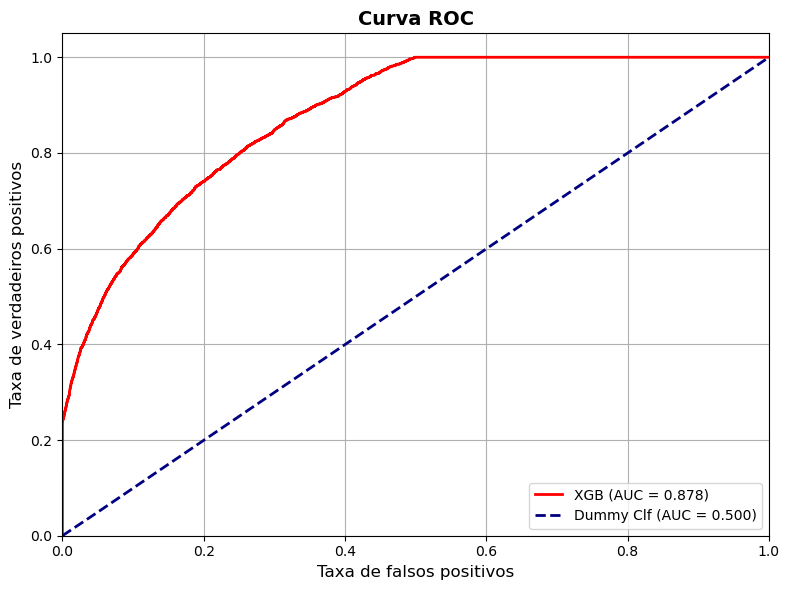

In [20]:
# curva ROC
from sklearn.metrics import roc_curve, auc
fpr_d, tpr_d, thresholds_d = roc_curve(y_train, dummy.predict_proba(X_train)[:, 1])
fpr, tpr, thresholds = roc_curve(y_train, pipeline.predict_proba(X_train)[:, 1])

# gráfico
plt.figure(figsize=(8, 6))

# Plot da curva ROC do seu Pipeline
plt.plot(fpr, tpr,
         color='red', 
         linewidth=2,
         label=f'XGB (AUC = {auc(fpr, tpr):.3f})')

# Plot da curva ROC do Dummy Classifier
plt.plot(fpr_d, tpr_d,
         color='navy', 
         linestyle='--',
         linewidth=2,
         label=f'Dummy Clf (AUC = {auc(fpr_d, tpr_d):.3f})')

# Configurações do gráfico
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de falsos positivos', fontsize=12)
plt.ylabel('Taxa de verdadeiros positivos', fontsize=12)
plt.title('Curva ROC', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.show()

### 📊 Métricas de classificação: Precisão, Recall e F1-score

Para além da acurácia, é importante analisar métricas que avaliam diferentes aspectos do modelo:  

- **Precisão (Precision):** entre as instâncias previstas como positivas, quantas realmente eram positivas.  
- **Recall (Sensibilidade):** entre todas as instâncias positivas reais, quantas foram corretamente identificadas.  
- **F1-score:** média harmônica entre precisão e recall, balanceando as duas métricas.  

Aqui comparamos o desempenho do **DummyClassifier** com o modelo treinado,  
para verificar se o modelo realmente traz ganhos nessas métricas fundamentais.


In [21]:
# recall, precisão e f1 no TREINO
from sklearn.metrics import precision_score, recall_score, f1_score

# Predições no treino
y_pred_dummy = dummy.predict(X_train)
y_pred_modelo = pipeline.predict(X_train)

# Dummy
prec_dummy = precision_score(y_train, y_pred_dummy)
rec_dummy  = recall_score(y_train, y_pred_dummy)
f1_dummy   = f1_score(y_train, y_pred_dummy)

# XGB
prec_modelo = precision_score(y_train, y_pred_modelo)
rec_modelo  = recall_score(y_train, y_pred_modelo)
f1_modelo   = f1_score(y_train, y_pred_modelo)

# Exibição
print("=== Desempenho no TREINO ===")
print(f"Dummy → Precisão: {prec_dummy:.1%} | Recall: {rec_dummy:.1%} | F1: {f1_dummy:.1%}")
print(f"XGB   → Precisão: {prec_modelo:.1%} | Recall: {rec_modelo:.1%} | F1: {f1_modelo:.1%}")


=== Desempenho no TREINO ===
Dummy → Precisão: 4.8% | Recall: 4.7% | F1: 4.8%
XGB   → Precisão: 9.4% | Recall: 100.0% | F1: 17.2%


## **Endpoint**

Alcançamos um modelo final do random forest  e avaliamos ele no conjunto de treinamento. Agora vamos salvar o modelo e avaliá-lo, com os demais, em uma estratégia de validação cruzada final. 

In [22]:
# salvar objeto pipeline completo
joblib.dump(pipeline, 'randomforest_pipeline_trained.joblib')

['randomforest_pipeline_trained.joblib']